# 🎬 Netflix Content Analysis
Python • Pandas • Plotly • Matplotlib • Seaborn • Numpy • EDA • Data Visualization

## Business Problem

Netflix has one of the world's largest streaming libraries. Understanding its content distribution, growth patterns, audience targeting, and geographical reach can provide valuable business insights.

This project performs Exploratory Data Analysis (EDA) on the Netflix Titles dataset to uncover trends, identify patterns, and present actionable insights through interactive visualizations.


## Objectives

- Understand Netflix's content distribution.
- Analyze trends in content growth.
- Explore country-wise production patterns.
- Identify the most common genres.
- Examine audience ratings.
- Derive business insights from the dataset.

## Dataset Overview
Source (Kaggle Netflix dataset)

#### Import Libraries

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#### Load Dataset

In [44]:
df=pd.read_csv("netflix_titles.csv")
shape=df.shape

#### Data Understanding

In [ ]:
print("No. of rows=",shape[0])
print("No. of columns=",shape[1])

In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

#### What each column represents

| Column       | Description                                             |
| ------------ | ------------------------------------------------------- |
| show_id      | Unique identifier assigned to each title                |
| type         | Specifies whether the content is a Movie or TV Show     |
| title        | Name of the content                                     |
| director     | Director(s) of the title                                |
| cast         | Main cast members appearing in the title                |
| country      | Country/countries where the content was produced        |
| date_added   | Date on which the title was added to Netflix            |
| release_year | Original release year of the title                      |
| rating       | Content maturity rating (e.g., TV-MA, TV-14, PG)        |
| duration     | Duration of the movie or number of seasons for TV Shows |
| listed_in    | Genre/category of the content                           |
| description  | Brief summary of the title                              |


#### Dataset Summary

| Attribute           | Description              |
| ------------------- | ------------------------ |
| Dataset Name        | Netflix Titles Dataset   |
| Total Records       | 8807                   |
| Total Features      | 12                      |
| Source              | Kaggle                   |
| Content Types       | Movies and TV Shows      |
| Time Period Covered | Based on dataset records |

The objective of this analysis is to explore Netflix's content library and identify patterns related to content type, ratings, genres, countries, and growth trends. The project aims to understand Netflix's content strategy and derive meaningful insights through data visualization and exploratory data analysis.

## Data Cleaning

#### Are there missing values? Where?

In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### Missing Value Handling

Missing values were identified and handled before performing the analysis. Records with missing values in critical columns such as country, rating, and date_added were removed to maintain data consistency and avoid misleading insights during country-wise, genre-wise, and trend analyses.

In [5]:
df=df.dropna()

#### Any columns modified?

<p>Yes in total 6 columns are modified which are:<br>-director<br>-cast<br>-country<br>-date_added<br>-rating<br>-duration</p>

# Exploratory Data Analysis

## Content Distribution Analysis

#### What is the distribution of content type (Movies vs TV Shows)?

In [6]:
df["type"].value_counts()

type
Movie      5185
TV Show     147
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Content type (Movies vs TV Shows)')

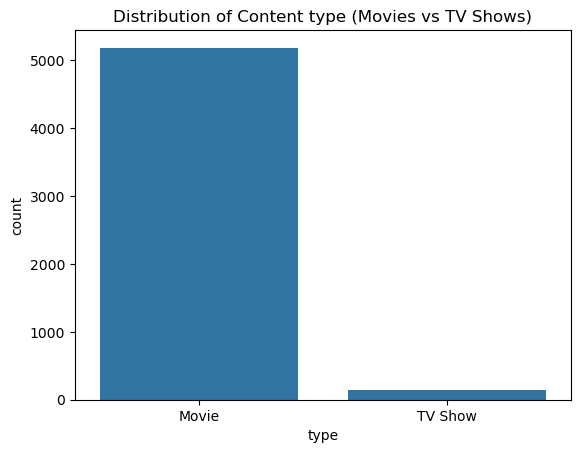

In [7]:
fig=sns.countplot(data=df,x="type")
fig.set_title("Distribution of Content type (Movies vs TV Shows)")

<pre>Insight:

Movies dominate the Netflix platform, with significantly higher count compared to TV Shows. 
This indicates that Netflix focuses more on movie content, although TV Shows also form a substantial portion.</pre>

## Rating & Audience Analysis
#### What is the distribution of ratings

In [8]:
df["rating"].value_counts()

rating
TV-MA       1822
TV-14       1214
R            778
PG-13        470
TV-PG        431
PG           275
TV-G          84
TV-Y7         76
TV-Y          76
NR            58
G             40
TV-Y7-FV       3
UR             3
NC-17          2
Name: count, dtype: int64

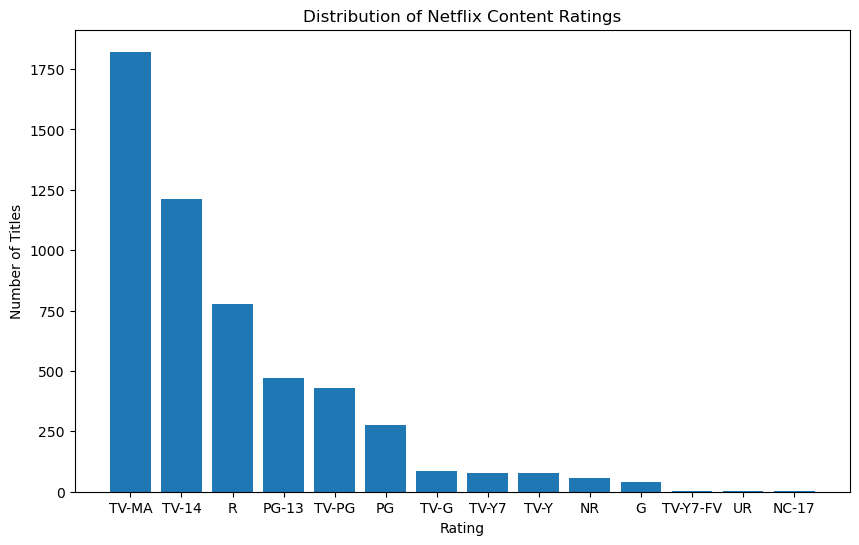

In [9]:
rating_count=dict(df["rating"].value_counts())
plt.figure(figsize=(10,6))
plt.bar(x=rating_count.keys(),height=rating_count.values())
plt.title('Distribution of Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.show()

#### Which audience category does Netflix target the most?

From the graph we can study that:
TV-MA is the most common rating category on Netflix, indicating that a large portion of the content is intended for mature audiences. TV-14 is the second most prevalent category, showing a strong focus on teenage and young adult viewers. Family-friendly categories such as TV-Y and G constitute a smaller share of the platform's content.

#### Are mature-content ratings more common than family-friendly ratings?

Yes, mature-content ratings are more common than family-friendly ratings. Suggesting that the users are majorly adults than families

## Country-Based Analysis

In [10]:
df["country"].value_counts()

country
United States                                   1846
India                                            875
United Kingdom                                   183
Canada                                           107
Spain                                             91
                                                ... 
Uruguay, Guatemala                                 1
Romania, Bulgaria, Hungary                         1
Philippines, United States                         1
India, United Kingdom, Canada, United States       1
United Arab Emirates, Jordan                       1
Name: count, Length: 604, dtype: int64

In [11]:
country_count=dict(df["country"].value_counts())
len(country_count)
country={}
for i in country_count.keys():
    y=i.split(", ")
    if len(y)>1:
        x=0
        while(x<len(y)):
            if y[x]=="":
                x+=1
                continue

            elif "," in y[x]:
                y[x]=y[x].split(",")[0]
            
            country[y[x]]=country.get(y[x],0)+country_count[i]
            x+=1

    else:
        if "," in y[0]:
            y[0]=y[0].split(",")[0]
        country[y[0]]=country.get(y[0],0)+country_count[i]

Some records contained malformed country values (trailing commas and blank entries) and were cleaned during preprocessing.

In [12]:
# extracting top 10 countries
top_10 = dict(sorted(country.items(), key=lambda x: x[1], reverse=True)[:10])

#### Country Data Cleaning



The country column contained multiple countries in a single record, inconsistent formatting, trailing commas, and blank entries. To ensure accurate country-level analysis, multiple-country records were split into individual countries and formatting inconsistencies were removed. This allowed each country to be counted independently during the analysis.

#### Which countries produce the most Netflix content?

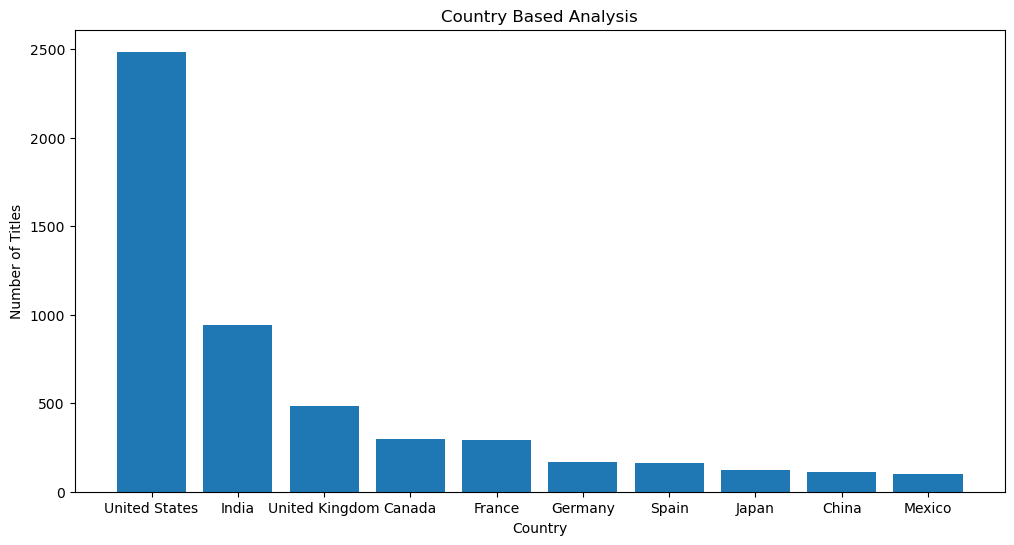

In [13]:
plt.figure(figsize=(12,6))
plt.bar(top_10.keys(),top_10.values())
plt.title('Country Based Analysis')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

The country-wise analysis reveals that the United States is the leading producer of Netflix content, significantly outperforming all other countries. India ranks second, while the United Kingdom holds the third position. The results indicate that Netflix's content catalog is largely driven by a small number of countries, with the United States contributing the largest share of titles available on the platform.

In [14]:
x={"country":[],"type":[]}
for i in df[df["type"]=="Movie"]["country"]:
    y=i.split(", ")
    j=0
    if len(y)>1:
        while j<len(y):
            if y[j]=="":
                j+=1
                continue
            elif "," in y[j]:
                y[j]=y[j].split(",")[0]

            x["country"].append(y[j])
            x["type"].append("Movie")

            j+=1


    else:
        if "," in y[0]:
            y[0]=y[0].split(",")[0]

        x["country"].append(y[0])
        x["type"].append("Movie")

            
for i in df[df["type"]=="TV Show"]["country"]:
    y=i.split(", ")
    j=0
    if len(y)>1:
        while j<len(y):
            if y[j]=="":
                j+=1
                continue
            elif "," in y[j]:
                y[j]=y[j].split(",")[0]

            x["country"].append(y[j])
            x["type"].append("TV Show")

            j+=1


    else:
        
        if "," in y[0]:
            y[0]=y[0].split(",")[0]

        x["country"].append(y[0])
        x["type"].append("TV Show")



Some records contained malformed country values (trailing commas and blank entries) and were cleaned during preprocessing.

In [15]:
result=pd.DataFrame(x)
result=result.groupby("type")["country"].value_counts().reset_index(name="count")
result

,type,country,count
0,Movie,United States,2444
1,Movie,India,932
2,Movie,United Kingdom,462
3,Movie,Canada,287
4,Movie,France,285
...,...,...,...
138,TV Show,Poland,1
139,TV Show,Russia,1
140,TV Show,Saudi Arabia,1
141,TV Show,Singapore,1


#### Which country dominates Movies?

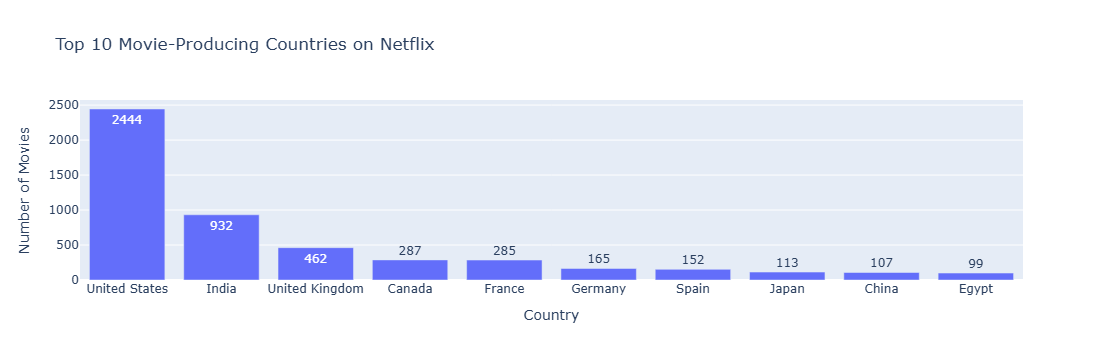

In [16]:
fig=px.bar(x=result[result["type"]=="Movie"]["country"].head(10), y=result[result["type"]=="Movie"]["count"].head(10), text_auto=True,
       
           title="Top 10 Movie-Producing Countries on Netflix")
fig.update_xaxes(title="Country")
fig.update_yaxes(title="Number of Movies")

The United States is the largest contributor of movies on Netflix, followed by India and the United Kingdom. This indicates that Netflix's movie catalog is primarily dominated by content from a few major production markets, with the United States contributing a significantly larger number of titles than other countries.

#### Which country dominates TV Shows?

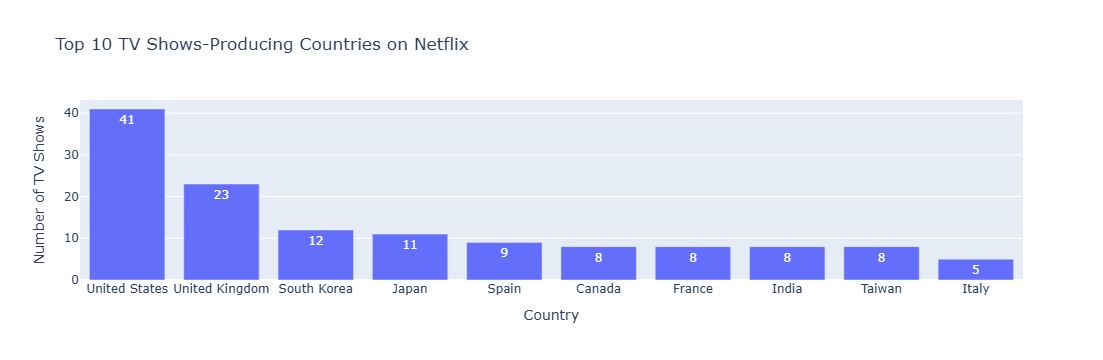

In [17]:
fig=px.bar(x=result[result["type"]=="TV Show"]["country"].head(10), y=result[result["type"]=="TV Show"]["count"].head(10), text_auto=True,
       
           title="Top 10 TV Shows-Producing Countries on Netflix")
fig.update_xaxes(title="Country")
fig.update_yaxes(title="Number of TV Shows")

The United States also leads in TV show production on Netflix, followed by the United Kingdom and South Korea. The results suggest that Netflix relies heavily on content from these countries for its television catalog, reflecting their strong entertainment industries and global audience reach.

## Genre Analysis

In [18]:
genre={"genre":[],"type":[]}
for i in df[df["type"]=="Movie"]["listed_in"]:
    y=i.split(", ")
    j=0
    if len(y)>1:
        while j<len(y):
            if y[j]=="":
                j+=1
                continue
            elif "," in y[j]:
                y[j]=y[j].split(",")[0]

            genre["genre"].append(y[j])
            genre["type"].append("Movie")

            j+=1


    else:
        if "," in y[0]:
            y[0]=y[0].split(",")[0]

        genre["genre"].append(y[0])
        genre["type"].append("Movie")

            
for i in df[df["type"]=="TV Show"]["listed_in"]:
    y=i.split(", ")
    j=0
    if len(y)>1:
        while j<len(y):
            genre["genre"].append(y[j])
            genre["type"].append("TV Show")
            j+=1


    else:
        genre["genre"].append(y[0])
        genre["type"].append("TV Show")

genre=pd.DataFrame(genre)

In [19]:
genre=genre.groupby("type")["genre"].value_counts().reset_index(name="count")
genre=genre.sort_values(by="count", ascending=False)
genre

,type,genre,count
0,Movie,International Movies,2369
1,Movie,Dramas,2293
2,Movie,Comedies,1553
3,Movie,Action & Adventure,806
4,Movie,Independent Movies,740
5,Movie,Romantic Movies,579
6,Movie,Thrillers,547
7,Movie,Children & Family Movies,503
8,Movie,Documentaries,391
9,Movie,Horror Movies,336


#### What are the most common genres on Netflix?

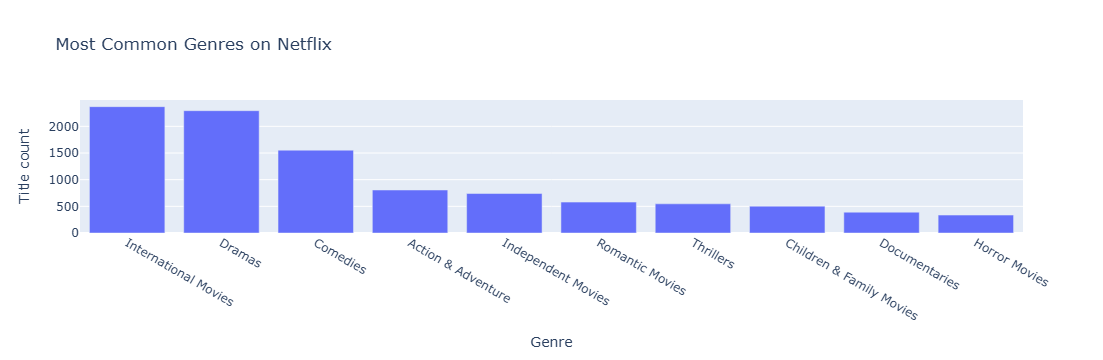

In [20]:
fig=px.bar(x=genre["genre"].head(10),y=genre["count"].head(10), title="Most Common Genres on Netflix")
fig.update_xaxes(title="Genre")
fig.update_yaxes(title="Title count")

International Movies, Dramas, and Comedies are the three most common genres on Netflix. This suggests that the platform prioritizes globally accessible content while offering a wide variety of entertainment through drama and comedy-based titles.

#### Which genres are more popular in Movies vs TV Shows

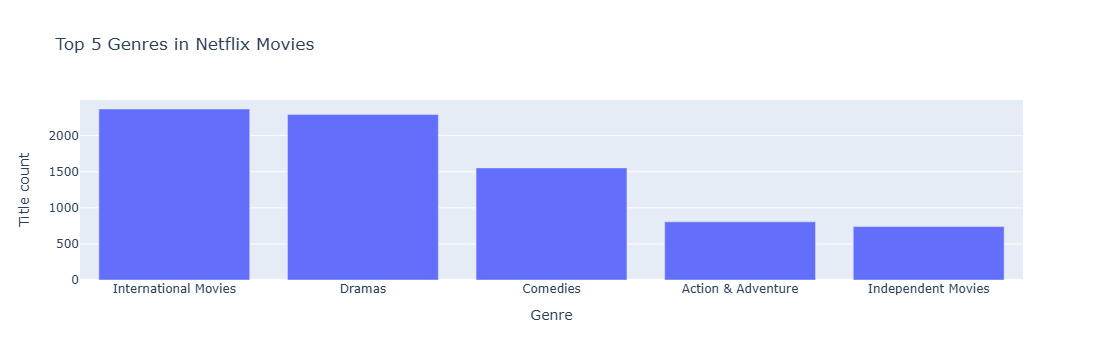

In [21]:
fig=px.bar(x=genre[genre["type"]=="Movie"]["genre"].head(5),y=genre[genre["type"]=="Movie"]["count"].head(5), title="Top 5 Genres in Netflix Movies")
fig.update_xaxes(title="Genre")
fig.update_yaxes(title="Title count")

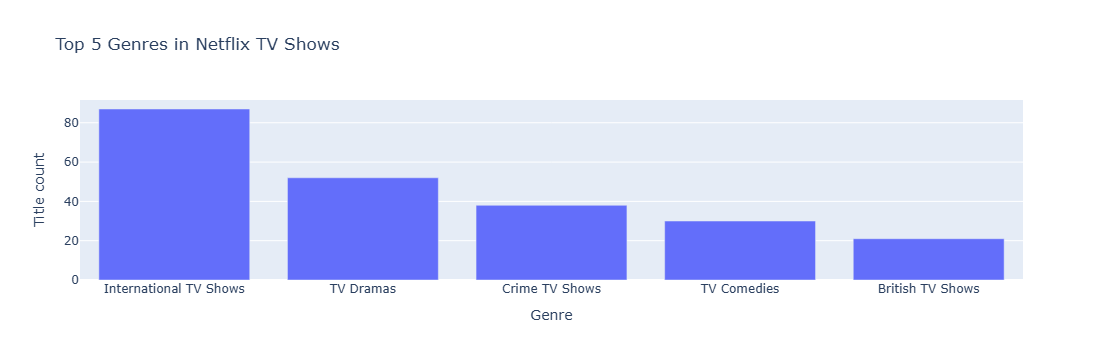

In [22]:
fig=px.bar(x=genre[genre["type"]=="TV Show"]["genre"].head(5),y=genre[genre["type"]=="TV Show"]["count"].head(5), 
           title="Top 5 Genres in Netflix TV Shows")
fig.update_xaxes(title="Genre")
fig.update_yaxes(title="Title count")

The genre distribution differs between Movies and TV Shows on Netflix. Movies are dominated by genres such as International Movies, Dramas, and Comedies, whereas TV Shows are primarily concentrated in genres like International TV Shows, TV Dramas, and Crime TV Shows. This suggests that Netflix tailors content categories differently for movie and television audiences.

## Trend Analysis

In [23]:
df["date_added"] = df["date_added"].str.strip()

df["year_added"] = pd.to_datetime(df["date_added"],errors="coerce").dt.year

In [24]:
yearly_growth = df["year_added"].value_counts().sort_index()

####  How has Netflix content grown over the years

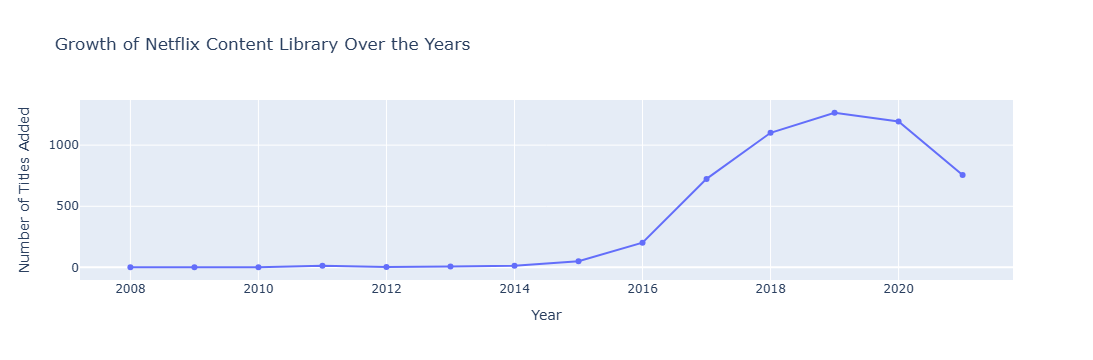

In [25]:
fig = px.line(
    x=yearly_growth.index,
    y=yearly_growth.values,
    markers=True,
    title="Growth of Netflix Content Library Over the Years"
)

fig.update_xaxes(title="Year")
fig.update_yaxes(title="Number of Titles Added")

fig.show()

Netflix experienced its most significant growth between 2016 and 2019, with the number of titles added increasing rapidly during this period. The platform reached its highest content additions in 2019. Although a slight decline is visible from 2020 onwards, Netflix continued to maintain a large and diverse content library compared to previous years.

#### When did Netflix experience the highest growth?

Netflix experienced its highest growth between 2016 and 2017, when the number of titles added to the platform increased sharply. This period marked the beginning of Netflix's rapid content expansion strategy. Although the highest number of titles was added in 2019, the most significant year-over-year growth occurred during 2016–2017.

In [26]:
yearly_growth_shows = pd.to_datetime(df[df["type"]=="TV Show"]["date_added"],errors="coerce").dt.year.value_counts().sort_index()
yearly_growth_movies = pd.to_datetime(df[df["type"]=="Movie"]["date_added"],errors="coerce").dt.year.value_counts().sort_index()

#### Are TV Shows increasing faster than Movies?

In [27]:
fig = px.line(
    x=yearly_growth_shows.index,
    y=yearly_growth_shows.values,
    markers=True,
    title="Growth of TV Shows on Netflix Content Library Over the Years"
)

fig.update_xaxes(title="Year")
fig.update_yaxes(title="Number of TV Shows Added")

fig1 = px.line(
    x=yearly_growth_movies.index,
    y=yearly_growth_movies.values,
    markers=True,
    title="Growth of Movies on Netflix Content Library Over the Years"
)

fig1.update_xaxes(title="Year")
fig1.update_yaxes(title="Number of Movies Added")

fig.show()

fig1.show()

Both Movies and TV Shows experienced significant growth after 2016. Movies contributed the majority of Netflix's content expansion, showing a sharp increase until 2019. TV Shows also grew steadily, especially between 2016 and 2020, indicating Netflix's increasing investment in episodic content. However, Movies remain the dominant content type on the platform.

## Advanced Insights

In [30]:
rating_trend = df.groupby(["year_added", "rating"]).size().reset_index(name="count")

#### What trends can be observed from audience ratings over time?

In [31]:
fig = px.line(
    rating_trend,
    x="year_added",
    y="count",
    color="rating",
    markers=True,
    title="Netflix Content Ratings Over Time"
)

fig.update_xaxes(title="Year")
fig.update_yaxes(title="Number of Titles")

fig.show()

The analysis shows that Netflix's content library experienced significant growth across all rating categories after 2016. TV-MA emerged as the dominant rating category, recording the highest number of titles and peaking around 2019. TV-14 also showed substantial growth during the same period, indicating Netflix's increasing focus on content targeted towards mature and young-adult audiences. Family-oriented ratings such as G and TV-G maintained relatively lower counts throughout the years. Overall, Netflix appears to prioritize content for older audiences while maintaining a diverse catalog for different age groups.

#### How does content strategy vary by country?

The United States follows the most diversified content strategy, contributing significantly to both Movies and TV Shows. India contributes heavily through Movies, while countries such as the United Kingdom and South Korea have a stronger presence in TV Shows and internationally popular content. These patterns suggest that Netflix adapts its content acquisition and production strategy based on regional strengths and audience preferences.

#### What major insights can be derived from the dataset overall?

##### Major Insights Derived from Netflix Dataset
1. Movies dominate Netflix's content library, significantly outnumbering TV Shows throughout the platform.
2. The United States is the largest contributor of Netflix content, followed by India and the United Kingdom, highlighting Netflix's strong presence in these regions.
3. International Movies, Dramas, and Comedies are the most popular genres, indicating Netflix's emphasis on globally appealing entertainment content.
4. Netflix experienced rapid expansion between 2016 and 2019, during which the number of titles added to the platform increased dramatically.
5. The highest content growth occurred between 2016 and 2017, marking the beginning of Netflix's aggressive content expansion strategy.
6. Although Movies remain dominant, TV Shows have shown steady growth over the years, reflecting Netflix's increasing investment in episodic and binge-worthy content.
7. TV-MA and TV-14 are the most common rating categories, suggesting that Netflix primarily targets mature and young-adult audiences.
8. Netflix maintains a highly diversified global content catalog, with titles originating from a wide range of countries and covering multiple genres, allowing the platform to cater to audiences across different regions and preferences.

The analysis reveals that Movies dominate Netflix's content library, with TV Shows showing steady growth over time. The United States, India, and the United Kingdom are the leading content-producing countries. International Movies, Dramas, and Comedies are the most common genres on the platform. Netflix experienced rapid content expansion between 2016 and 2019 and increasingly focused on mature audiences through TV-MA and TV-14 rated content. The platform's globally diverse catalog reflects its strategy of serving audiences across multiple regions and demographics.

## Limitations

The analysis is based solely on the available Netflix dataset and does not include viewer engagement metrics such as watch time, user ratings, or subscription data. Therefore, the findings represent content distribution and platform trends rather than audience preferences or content performance.

## Conclusion

#### What are the final key takeaways from the analysis?

The analysis highlights Netflix's transformation into a global content platform with a highly diverse catalog. Movies remain the dominant content type, while TV Shows continue to grow steadily. The platform experienced its most significant expansion between 2016 and 2019, supported by contributions from major content-producing countries such as the United States, India, and the United Kingdom. Netflix's content portfolio is largely driven by International Movies, Dramas, and Comedies, enabling it to appeal to a broad global audience.

#### What patterns define Netflix’s content strategy?

Netflix's content strategy is characterized by rapid content expansion, global diversification, and strong audience segmentation. The platform balances a large movie catalog with a growing TV Show library while prioritizing mature and young-adult audiences through TV-MA and TV-14 rated content. The prominence of international content demonstrates Netflix's commitment to regional storytelling and global accessibility. These patterns reflect Netflix's goal of maintaining a diverse and scalable content ecosystem capable of serving audiences worldwide. 